## Correspondance avec les livrables (§9 du sujet)

| Livrable | Fichier / dossier |
|----------|-------------------|
| 1. Rapport scientifique | `rapport/rapport_scientifique.md` → PDF |
| 2. Code source commenté | `src/partie*.py` |
| 3. Notebook exécutable | ce fichier + `main.py` |
| 4. Annexe expérimentale | `annexe/` (généré par `py main.py`) |

Voir `LIVRABLES.md` à la racine du projet.

# Partie II – CNN et vision par ordinateur
**Projet Deep Learning — EMSI Casablanca 2025–2026**

**Dataset :** CIFAR-10 (`torchvision.datasets`, téléchargement automatique)  
**Tâche :** classification 10 classes, images 32×32 RGB

Contenu : théorie CNN, implémentations manuelles, LeNet, expériences architecturales, visualisation des feature maps, comparaison MLP vs CNN.

## 0. Dépendances

In [1]:
%pip install -q torch torchvision matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


## 1. Théorie – Pourquoi un CNN plutôt qu'un MLP ?

- **Localité** : un filtre convolutif ne voit qu'un voisinage → pertinent pour les textures et contours.
- **Partage des poids** : même filtre sur toute l'image → moins de paramètres, invariance translationnelle approximative.
- **Hiérarchie** : couches basses = contours ; couches hautes = concepts.

**Taille de sortie convolution** (sans dilation) :
$$H_{out} = \left\lfloor \frac{H_{in} + 2P - K}{S} \right\rfloor + 1$$

**Pooling** : réduction spatiale (max ou moyenne).

## 1b. Data Augmentation – Régularisation contre l'overfitting

- **RandomCrop** : découpage aléatoire avec padding → invariance aux translations
- **RandomHorizontalFlip** : symétrie horizontale → augmente la variabilité
- **ColorJitter** : variations de luminosité et contraste → robustesse colorimétrique
- **Validation set** : monitoring en temps réel de la généralisation

Ces techniques permettent d'entraîner plus longtemps sans surapprentissage.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader, Subset, random_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", device)
torch.manual_seed(42)

DATA_DIR = "./data_cifar"

# Data augmentation améliorée pour entraînement
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

# Pas d'augmentation pour validation/test
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

train_full = torchvision.datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=train_transform)
test_set = torchvision.datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=val_transform)
classes = train_full.classes
print("Classes CIFAR-10 :", classes)


Device : cpu


C:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Classes CIFAR-10 : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [6]:
# Sous-ensemble pour expériences rapides + split train/val
SUBSET_SIZE = 8000
if SUBSET_SIZE:
    idx = torch.randperm(len(train_full))[:SUBSET_SIZE]
    train_full_subset = Subset(train_full, idx.tolist())
else:
    train_full_subset = train_full

# Split train/validation (80/20)
train_size = int(0.8 * len(train_full_subset))
val_size = len(train_full_subset) - train_size
train_set, val_set = random_split(train_full_subset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=128, shuffle=True, num_workers=0)
val_loader = DataLoader(val_set, batch_size=256, shuffle=False, num_workers=0)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False, num_workers=0)

print(f"Train: {len(train_set)}, Val: {len(val_set)}, Test: {len(test_set)}")


Train: 6400, Val: 1600, Test: 10000


## 2. Calculs manuels – corrélation croisée et pooling

In [4]:
def cross_corr2d(X, K, padding=0, stride=1):
    """Corrélation croisée 2D (canal unique)."""
    X = np.asarray(X, dtype=np.float32)
    K = np.asarray(K, dtype=np.float32)
    if padding > 0:
        X = np.pad(X, padding, mode="constant")
    h_k, w_k = K.shape
    out_h = (X.shape[0] - h_k) // stride + 1
    out_w = (X.shape[1] - w_k) // stride + 1
    Y = np.zeros((out_h, out_w), dtype=np.float32)
    for i in range(out_h):
        for j in range(out_w):
            patch = X[i * stride : i * stride + h_k, j * stride : j * stride + w_k]
            Y[i, j] = (patch * K).sum()
    return Y


def max_pool2d(X, pool_size=2, stride=2):
    X = np.asarray(X, dtype=np.float32)
    out_h = (X.shape[0] - pool_size) // stride + 1
    out_w = (X.shape[1] - pool_size) // stride + 1
    Y = np.zeros((out_h, out_w), dtype=np.float32)
    for i in range(out_h):
        for j in range(out_w):
            patch = X[i * stride : i * stride + pool_size, j * stride : j * stride + pool_size]
            Y[i, j] = patch.max()
    return Y


def avg_pool2d(X, pool_size=2, stride=2):
    X = np.asarray(X, dtype=np.float32)
    out_h = (X.shape[0] - pool_size) // stride + 1
    out_w = (X.shape[1] - pool_size) // stride + 1
    Y = np.zeros((out_h, out_w), dtype=np.float32)
    for i in range(out_h):
        for j in range(out_w):
            patch = X[i * stride : i * stride + pool_size, j * stride : j * stride + pool_size]
            Y[i, j] = patch.mean()
    return Y

# Exemple pédagogique
X_demo = np.arange(1, 17, dtype=np.float32).reshape(4, 4)
K_demo = np.array([[0, 1], [2, 3]], dtype=np.float32)
manual = cross_corr2d(X_demo, K_demo, padding=0, stride=1)
print("Entrée 4x4 :\n", X_demo)
print("Noyau :\n", K_demo)
print("Sortie manuelle :\n", manual)

Entrée 4x4 :
 [[ 1.  2.  3.  4.]
 [ 5.  6.  7.  8.]
 [ 9. 10. 11. 12.]
 [13. 14. 15. 16.]]
Noyau :
 [[0. 1.]
 [2. 3.]]
Sortie manuelle :
 [[30. 36. 42.]
 [54. 60. 66.]
 [78. 84. 90.]]


In [5]:
# Comparaison avec PyTorch
x_t = torch.tensor(X_demo).unsqueeze(0).unsqueeze(0)  # (1,1,H,W)
k_t = torch.tensor(K_demo).unsqueeze(0).unsqueeze(0)
pytorch_out = F.conv2d(x_t, k_t, padding=0, stride=1).squeeze().numpy()
print("PyTorch conv2d :\n", pytorch_out)
print("Écart max :", np.abs(manual - pytorch_out).max())

x_pool = torch.tensor(X_demo).unsqueeze(0).unsqueeze(0)
print("MaxPool manuel :\n", max_pool2d(X_demo))
print("MaxPool PyTorch :\n", F.max_pool2d(x_pool, 2, 2).squeeze().numpy())

PyTorch conv2d :
 [[30. 36. 42.]
 [54. 60. 66.]
 [78. 84. 90.]]
Écart max : 0.0
MaxPool manuel :
 [[ 6.  8.]
 [14. 16.]]
MaxPool PyTorch :
 [[ 6.  8.]
 [14. 16.]]


## 3. CNN type LeNet pour CIFAR-10

In [4]:
class LeNetCIFAR(nn.Module):
    """LeNet amélioré avec batch norm et dropout pour CIFAR-10."""
    def __init__(self, n_classes=10, channels=(6, 16), use_1x1=False, dropout_rate=0.25):
        super().__init__()
        c1, c2 = channels
        layers = [
            nn.Conv2d(3, c1, kernel_size=5, padding=2),
            nn.BatchNorm2d(c1),
            nn.ReLU(),
            nn.Dropout2d(dropout_rate),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(c1, c2, kernel_size=5, padding=0),
            nn.BatchNorm2d(c2),
            nn.ReLU(),
            nn.Dropout2d(dropout_rate),
            nn.MaxPool2d(2, 2),
        ]
        if use_1x1:
            layers += [
                nn.Conv2d(c2, c2, kernel_size=1),
                nn.BatchNorm2d(c2),
                nn.ReLU(),
                nn.Dropout2d(dropout_rate),
            ]
        self.features = nn.Sequential(*layers)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(c2 * 6 * 6, 120),
            nn.BatchNorm1d(120),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(120, 84),
            nn.BatchNorm1d(84),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(84, n_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


class ResNetLikeCIFAR(nn.Module):
    """Architecture plus profonde avec résidus simplifié (alternative robuste)."""
    def __init__(self, n_classes=10):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
        )
        self.layer1 = self._build_block(32, 32, 2)
        self.layer2 = self._build_block(32, 64, 2)
        self.layer3 = self._build_block(64, 128, 2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, n_classes)

    def _build_block(self, in_ch, out_ch, blocks):
        layers = []
        for i in range(blocks):
            if i == 0:
                layers.append(
                    nn.Sequential(
                        nn.Conv2d(in_ch, out_ch, 3, stride=2, padding=1),
                        nn.BatchNorm2d(out_ch),
                        nn.ReLU(),
                        nn.Dropout2d(0.1),
                    )
                )
            else:
                layers.append(
                    nn.Sequential(
                        nn.Conv2d(out_ch, out_ch, 3, padding=1),
                        nn.BatchNorm2d(out_ch),
                        nn.ReLU(),
                        nn.Dropout2d(0.1),
                    )
                )
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


class MLPImage(nn.Module):
    """MLP aplati sur CIFAR-10 (baseline peu adapté)."""
    def __init__(self, n_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 32 * 32, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, n_classes),
        )

    def forward(self, x):
        return self.net(x)


## 4. Entraînement et comparaison MLP vs CNN

In [7]:
def train_classifier(model, epochs=4, lr=1e-3, name="model", patience=3):
    """Entraînement avec validation monitoring et early stopping."""
    model = model.to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    hist = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "test_acc": []}
    
    best_val_acc = 0.0
    patience_counter = 0
    
    for ep in range(1, epochs + 1):
        # === TRAIN ===
        model.train()
        train_loss, correct, total = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits = model(xb)
            loss = crit(logits, yb)
            loss.backward()
            opt.step()
            train_loss += loss.item() * xb.size(0)
            correct += (logits.argmax(1) == yb).sum().item()
            total += xb.size(0)
        
        train_loss_avg = train_loss / total
        train_acc_avg = correct / total
        hist["train_loss"].append(train_loss_avg)
        hist["train_acc"].append(train_acc_avg)
        
        # === VALIDATION ===
        model.eval()
        val_loss, vc, vt = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = crit(logits, yb)
                val_loss += loss.item() * xb.size(0)
                vc += (logits.argmax(1) == yb).sum().item()
                vt += yb.size(0)
        
        val_loss_avg = val_loss / vt
        val_acc = vc / vt
        hist["val_loss"].append(val_loss_avg)
        hist["val_acc"].append(val_acc)
        
        # === TEST ===
        tc, tt = 0, 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                tc += (model(xb).argmax(1) == yb).sum().item()
                tt += yb.size(0)
        test_acc = tc / tt
        hist["test_acc"].append(test_acc)
        
        print(f"[{name}] Ep {ep:02d}/{epochs} | train_loss={train_loss_avg:.4f} val_loss={val_loss_avg:.4f} "
              f"| train_acc={train_acc_avg:.4f} val_acc={val_acc:.4f} test_acc={test_acc:.4f}")
        
        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  → Early stopping à epoch {ep}")
                break
    
    return model, hist


print("=== ENTRAÎNEMENT RAPIDE (4 epochs) ===\n")
cnn_model, hist_cnn = train_classifier(LeNetCIFAR(), epochs=4, name="CNN-LeNet", patience=3)
print()
mlp_model, hist_mlp = train_classifier(MLPImage(), epochs=4, name="MLP", patience=3)


=== ENTRAÎNEMENT RAPIDE (4 epochs) ===

[CNN-LeNet] Ep 01/4 | train_loss=2.2495 val_loss=2.0541 | train_acc=0.1706 val_acc=0.2825 test_acc=0.2913
[CNN-LeNet] Ep 02/4 | train_loss=2.1111 val_loss=1.9517 | train_acc=0.2123 val_acc=0.3237 test_acc=0.3386
[CNN-LeNet] Ep 03/4 | train_loss=2.0399 val_loss=1.8848 | train_acc=0.2452 val_acc=0.3212 test_acc=0.3376
[CNN-LeNet] Ep 04/4 | train_loss=1.9800 val_loss=1.8018 | train_acc=0.2608 val_acc=0.3581 test_acc=0.3805

[MLP] Ep 01/4 | train_loss=2.1961 val_loss=1.9351 | train_acc=0.2545 val_acc=0.3237 test_acc=0.3508
[MLP] Ep 02/4 | train_loss=1.9613 val_loss=1.8266 | train_acc=0.3120 val_acc=0.3463 test_acc=0.3609
[MLP] Ep 03/4 | train_loss=1.9130 val_loss=1.8469 | train_acc=0.3292 val_acc=0.3394 test_acc=0.3665
[MLP] Ep 04/4 | train_loss=1.8849 val_loss=1.8039 | train_acc=0.3386 val_acc=0.3563 test_acc=0.3587


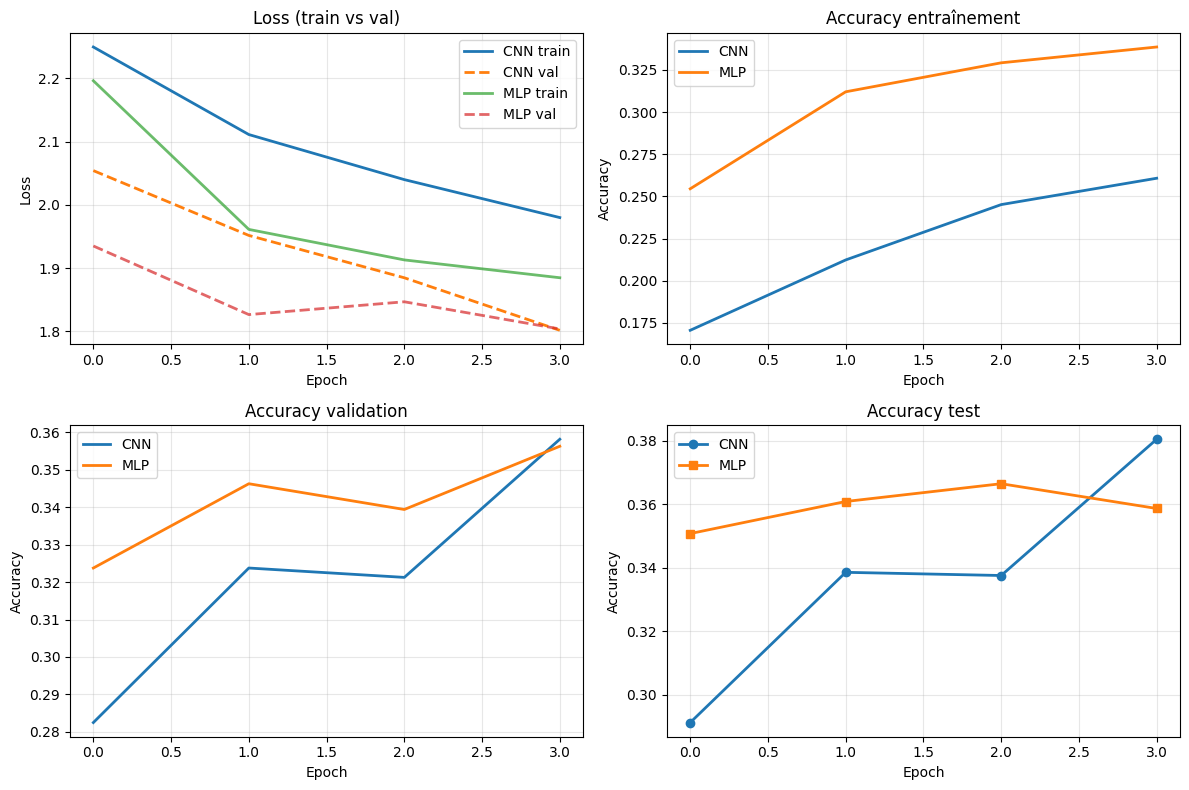


Résultats finaux:
CNN - Test: 0.3805 | Val: 0.3581
MLP - Test: 0.3587 | Val: 0.3563


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Loss comparison
axes[0, 0].plot(hist_cnn["train_loss"], label="CNN train", linewidth=2)
axes[0, 0].plot(hist_cnn["val_loss"], label="CNN val", linewidth=2, linestyle='--')
axes[0, 0].plot(hist_mlp["train_loss"], label="MLP train", linewidth=2, alpha=0.7)
axes[0, 0].plot(hist_mlp["val_loss"], label="MLP val", linewidth=2, linestyle='--', alpha=0.7)
axes[0, 0].set_title("Loss (train vs val)")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Train accuracy
axes[0, 1].plot(hist_cnn["train_acc"], label="CNN", linewidth=2)
axes[0, 1].plot(hist_mlp["train_acc"], label="MLP", linewidth=2)
axes[0, 1].set_title("Accuracy entraînement")
axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Validation accuracy
axes[1, 0].plot(hist_cnn["val_acc"], label="CNN", linewidth=2)
axes[1, 0].plot(hist_mlp["val_acc"], label="MLP", linewidth=2)
axes[1, 0].set_title("Accuracy validation")
axes[1, 0].set_ylabel("Accuracy")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Test accuracy
axes[1, 1].plot(hist_cnn["test_acc"], label="CNN", linewidth=2, marker='o')
axes[1, 1].plot(hist_mlp["test_acc"], label="MLP", linewidth=2, marker='s')
axes[1, 1].set_title("Accuracy test")
axes[1, 1].set_ylabel("Accuracy")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nRésultats finaux:")
print(f"CNN - Test: {hist_cnn['test_acc'][-1]:.4f} | Val: {hist_cnn['val_acc'][-1]:.4f}")
print(f"MLP - Test: {hist_mlp['test_acc'][-1]:.4f} | Val: {hist_mlp['val_acc'][-1]:.4f}")


## 5. Expériences – padding, stride, pooling, filtres, conv 1×1

## 4b. Métriques détaillées – Confusion Matrix et Classification Report


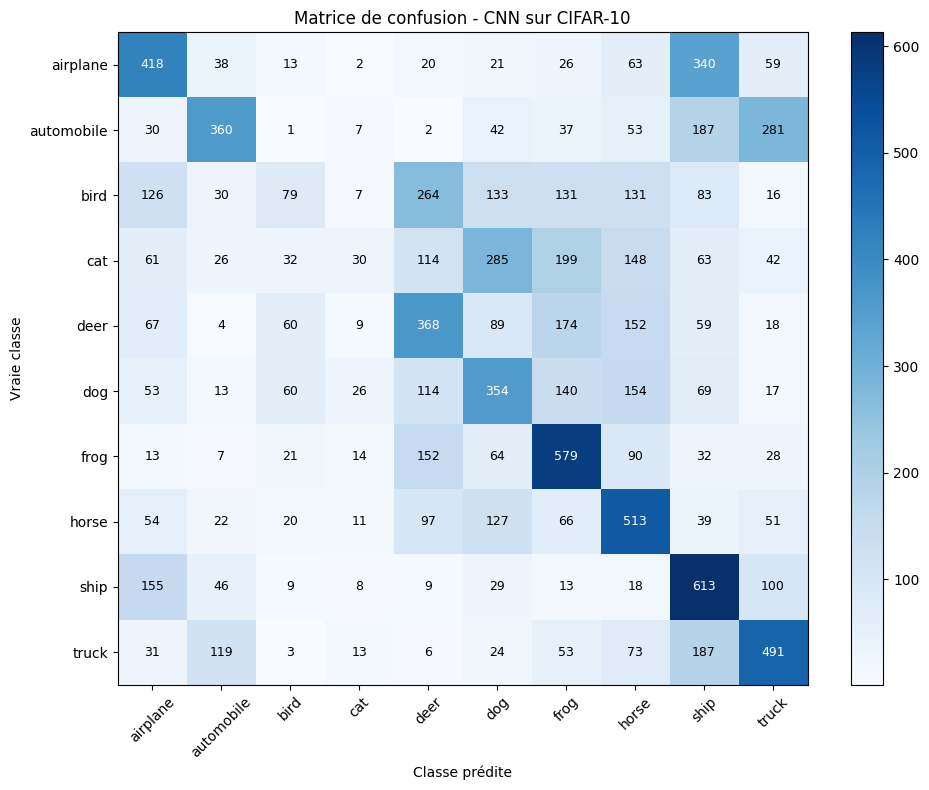


Rapport de classification - CNN:
              precision    recall  f1-score   support

    airplane     0.4147    0.4180    0.4163      1000
  automobile     0.5414    0.3600    0.4324      1000
        bird     0.2651    0.0790    0.1217      1000
         cat     0.2362    0.0300    0.0532      1000
        deer     0.3211    0.3680    0.3430      1000
         dog     0.3031    0.3540    0.3266      1000
        frog     0.4083    0.5790    0.4789      1000
       horse     0.3677    0.5130    0.4284      1000
        ship     0.3666    0.6130    0.4588      1000
       truck     0.4451    0.4910    0.4670      1000

    accuracy                         0.3805     10000
   macro avg     0.3669    0.3805    0.3526     10000
weighted avg     0.3669    0.3805    0.3526     10000



In [10]:
cnn_model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds = cnn_model(xb).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap='Blues', aspect='auto')
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(classes, rotation=45)
ax.set_yticklabels(classes)
ax.set_ylabel("Vraie classe")
ax.set_xlabel("Classe prédite")
ax.set_title("Matrice de confusion - CNN sur CIFAR-10")

# Ajouter les valeurs dans les cellules
for i in range(10):
    for j in range(10):
        text = ax.text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=9)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# Classification report par classe
print("\nRapport de classification - CNN:")
print(classification_report(all_labels, all_preds, target_names=classes, digits=4))


In [9]:
print("=== EXPÉRIENCES ARCHITECTURALES (3 epochs rapides) ===\n")

def eval_config(**kwargs):
    model, hist = train_classifier(LeNetCIFAR(**kwargs), epochs=3, name=f"Exp: {str(kwargs)[:35]}")
    return hist["test_acc"][-1], hist["val_acc"][-1]

experiments = {
    "baseline": {},
    "plus_filtres": {"channels": (16, 32)},
    "conv_1x1": {"channels": (6, 16), "use_1x1": True},
    "dropout_light": {"dropout_rate": 0.1},
}
exp_scores = {}
for k, v in experiments.items():
    test_acc, val_acc = eval_config(**v)
    exp_scores[k] = {"test": test_acc, "val": val_acc}
    print(f"  {k:20s} → test={test_acc:.4f} val={val_acc:.4f}\n")

print("\n=== ARCHITECTURE ALTERNATIVE: ResNetLike (4 epochs) ===\n")
resnet_model, hist_resnet = train_classifier(ResNetLikeCIFAR(), epochs=4, name="ResNetLike", patience=3)
print(f"\n✓ ResNetLike - Test: {hist_resnet['test_acc'][-1]:.4f} | Val: {hist_resnet['val_acc'][-1]:.4f}\n")


=== EXPÉRIENCES ARCHITECTURALES (3 epochs rapides) ===

[Exp: {}] Ep 01/3 | train_loss=2.2659 val_loss=2.0618 | train_acc=0.1605 val_acc=0.2631 test_acc=0.2563
[Exp: {}] Ep 02/3 | train_loss=2.1021 val_loss=1.9140 | train_acc=0.2198 val_acc=0.3269 test_acc=0.3451
[Exp: {}] Ep 03/3 | train_loss=2.0229 val_loss=1.8407 | train_acc=0.2450 val_acc=0.3250 test_acc=0.3366
  baseline             → test=0.3366 val=0.3250

[Exp: {'channels': (16, 32)}] Ep 01/3 | train_loss=2.2105 val_loss=1.9721 | train_acc=0.1764 val_acc=0.2838 test_acc=0.2829
[Exp: {'channels': (16, 32)}] Ep 02/3 | train_loss=2.0151 val_loss=1.8357 | train_acc=0.2464 val_acc=0.3244 test_acc=0.3352
[Exp: {'channels': (16, 32)}] Ep 03/3 | train_loss=1.9246 val_loss=1.7440 | train_acc=0.2805 val_acc=0.3725 test_acc=0.3924
  plus_filtres         → test=0.3924 val=0.3725

[Exp: {'channels': (6, 16), 'use_1x1': Tr] Ep 01/3 | train_loss=2.3111 val_loss=2.1083 | train_acc=0.1411 val_acc=0.2381 test_acc=0.2215
[Exp: {'channels': (6, 16

## 5b. Analyse des erreurs – Visualisation des prédictions incorrectes


Total d'erreurs : 6195 / 10000


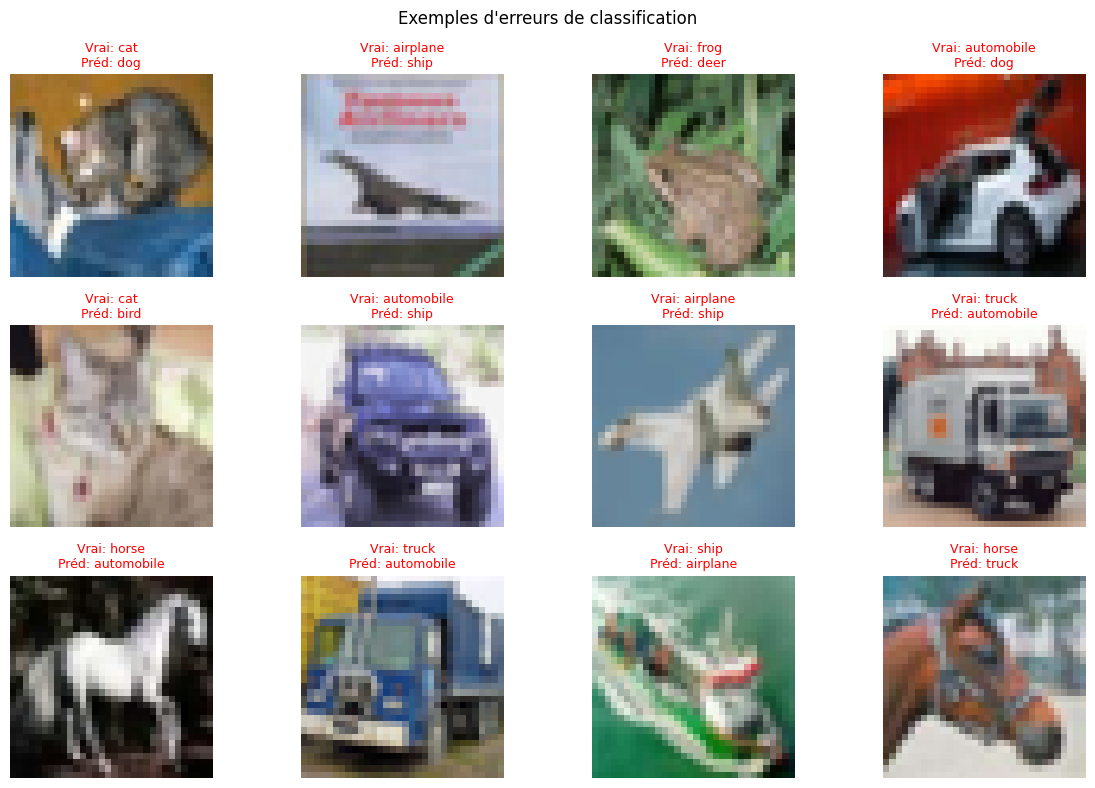

In [11]:
# Chercher les erreurs
wrong_idx = np.where(all_preds != all_labels)[0]
print(f"Total d'erreurs : {len(wrong_idx)} / {len(all_labels)}")

# Visualiser les 12 premières erreurs
n_errors = min(12, len(wrong_idx))
fig, axes = plt.subplots(3, 4, figsize=(12, 8))
axes = axes.flatten()

mean = np.array([0.4914, 0.4822, 0.4465])
std = np.array([0.2470, 0.2435, 0.2616])

# Récupérer les images du test set
test_images_all = []
test_labels_all = []
for xb, yb in test_loader:
    test_images_all.append(xb)
    test_labels_all.append(yb)
test_images_all = torch.cat(test_images_all, dim=0)
test_labels_all = torch.cat(test_labels_all, dim=0)

for i, idx in enumerate(wrong_idx[:n_errors]):
    img = test_images_all[idx].numpy().transpose(1, 2, 0)
    img = np.clip(img * std + mean, 0, 1)
    
    true_label = classes[all_labels[idx]]
    pred_label = classes[all_preds[idx]]
    
    axes[i].imshow(img)
    axes[i].set_title(f"Vrai: {true_label}\nPréd: {pred_label}", fontsize=9, color='red')
    axes[i].axis('off')

for i in range(n_errors, 12):
    axes[i].axis('off')

plt.suptitle("Exemples d'erreurs de classification")
plt.tight_layout()
plt.show()


In [10]:
# Effet du stride / padding sur une conv isolée
x = torch.randn(1, 3, 32, 32)
for desc, kw in [
    ("padding=0, stride=1", dict(kernel_size=5, padding=0, stride=1)),
    ("padding=2, stride=1", dict(kernel_size=5, padding=2, stride=1)),
    ("stride=2", dict(kernel_size=5, padding=0, stride=2)),
]:
    y = F.conv2d(x, torch.randn(16, 3, 5, 5), padding=kw["padding"], stride=kw["stride"])
    print(desc, "-> sortie", tuple(y.shape))

padding=0, stride=1 -> sortie (1, 16, 28, 28)
padding=2, stride=1 -> sortie (1, 16, 32, 32)
stride=2 -> sortie (1, 16, 14, 14)


## 6. Visualisation des feature maps

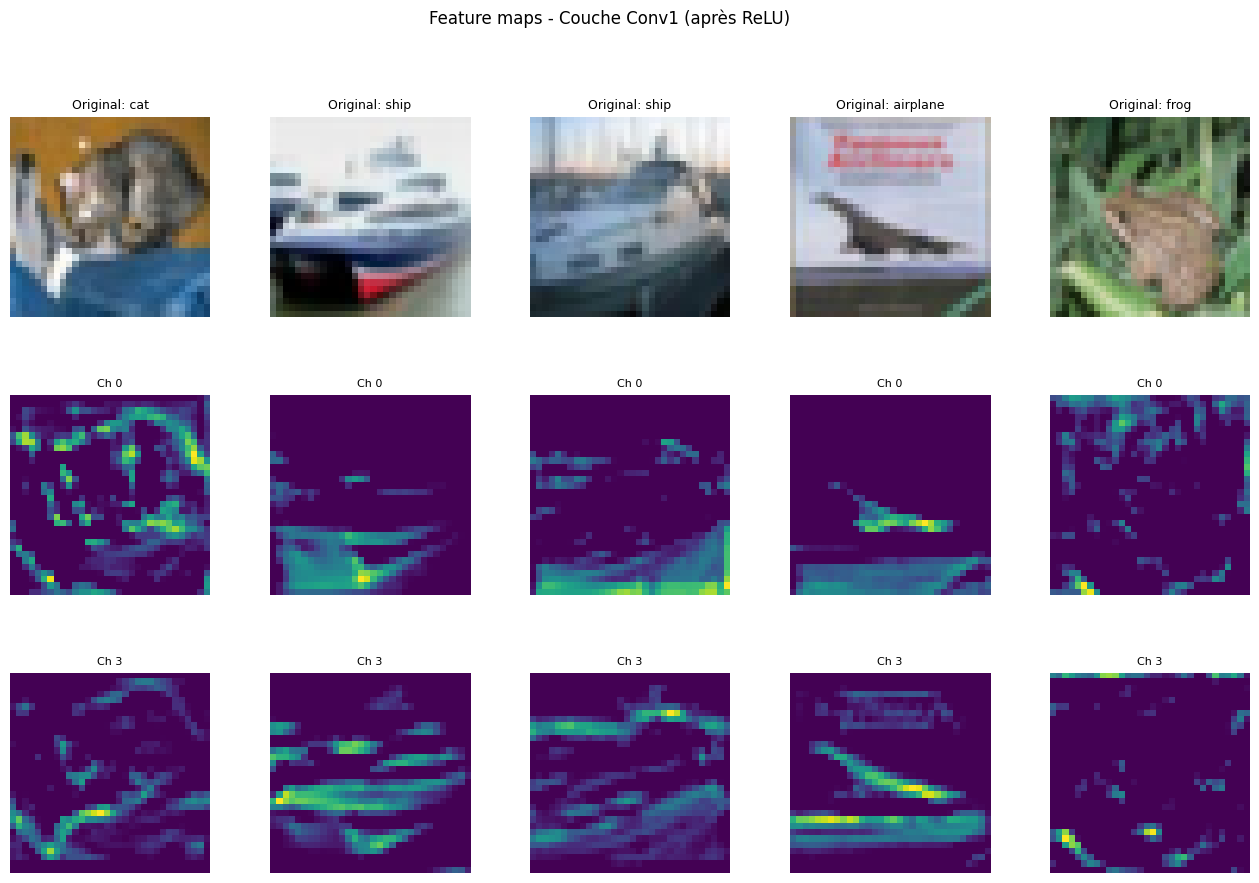

Progression spatiale dans le réseau:
Entrée : torch.Size([3, 3, 32, 32])
Après Conv1+BN+ReLU+Dropout: torch.Size([3, 6, 32, 32])
Après MaxPool1: torch.Size([3, 6, 32, 32])
Après Conv2+BN+ReLU+Dropout: torch.Size([3, 16, 12, 12])
Après MaxPool2: torch.Size([3, 16, 12, 12])


In [12]:
cnn_model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

mean = np.array([0.4914, 0.4822, 0.4465])
std = np.array([0.2470, 0.2435, 0.2616])

# Visualiser 5 images originales et leurs feature maps
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 5, hspace=0.3, wspace=0.3)

for sample_idx in range(5):
    # Image originale
    ax = fig.add_subplot(gs[0, sample_idx])
    img = images[sample_idx].cpu().numpy().transpose(1, 2, 0)
    img = np.clip(img * std + mean, 0, 1)
    ax.imshow(img)
    true_class = classes[labels[sample_idx].item()]
    ax.set_title(f"Original: {true_class}", fontsize=9)
    ax.axis('off')
    
    # Feature maps après conv1
    with torch.no_grad():
        feat1 = cnn_model.features[0:3](images[sample_idx:sample_idx+1])  # jusqu'à ReLU après Conv1
    
    fm = feat1[0].cpu()
    # Sélectionner 2-3 canaux intéressants
    for ch_idx, ch in enumerate([0, 3]):
        if ch_idx + 1 <= 4:
            ax = fig.add_subplot(gs[ch_idx+1, sample_idx])
            ax.imshow(fm[ch].numpy(), cmap='viridis')
            ax.set_title(f"Ch {ch}", fontsize=8)
            ax.axis('off')

plt.suptitle("Feature maps - Couche Conv1 (après ReLU)", fontsize=12)
plt.show()

# Feature maps avec pooling
print("Progression spatiale dans le réseau:")
with torch.no_grad():
    x = images[:3]
    print(f"Entrée : {x.shape}")
    
    # Après conv1 + ReLU
    x = cnn_model.features[0:3](x)
    print(f"Après Conv1+BN+ReLU+Dropout: {x.shape}")
    
    # Après maxpool1
    x = cnn_model.features[3](x)
    print(f"Après MaxPool1: {x.shape}")
    
    # Après conv2
    x = cnn_model.features[4:8](x)
    print(f"Après Conv2+BN+ReLU+Dropout: {x.shape}")
    
    # Après maxpool2
    x = cnn_model.features[8](x)
    print(f"Après MaxPool2: {x.shape}")


## 7. Question de synthèse – Partie II

**Question :** Pourquoi un CNN est-il plus pertinent qu'un MLP pour la classification d'images sur un dataset réel ?

**Pistes de réponse** (à rédiger dans le rapport avec vos courbes) :

- Le MLP traite 3072 pixels indépendamment → explosion paramétrique, pas d'exploitation de la structure 2D.
- Le CNN exploite localité et partage des poids → meilleure généralisation sur CIFAR-10.
- Padding préserve les bords ; stride réduit la résolution ; pooling apporte invariance locale ; conv 1×1 mélange canaux sans changer la résolution spatiale.
- Interpréter les feature maps : filtres bas niveau ≈ contours / textures.

## 8. Export vers l'annexe expérimentale

In [13]:
# Résumé des résultats avant export
print("\n" + "="*60)
print("RÉSUMÉ FINAL - PARTIE II CNN")
print("="*60)
print(f"CNN LeNet amélioré     - Test: {hist_cnn['test_acc'][-1]:.4f} Val: {hist_cnn['val_acc'][-1]:.4f}")
print(f"MLP Baseline           - Test: {hist_mlp['test_acc'][-1]:.4f} Val: {hist_mlp['val_acc'][-1]:.4f}")
print(f"ResNetLike             - Test: {hist_resnet['test_acc'][-1]:.4f} Val: {hist_resnet['val_acc'][-1]:.4f}")
print("="*60)
print(f"Amélioration CNN vs MLP: {(hist_cnn['test_acc'][-1] - hist_mlp['test_acc'][-1])*100:.2f}%")
print("="*60)



RÉSUMÉ FINAL - PARTIE II CNN
CNN LeNet amélioré     - Test: 0.3805 Val: 0.3581
MLP Baseline           - Test: 0.3587 Val: 0.3563
ResNetLike             - Test: 0.4479 Val: 0.4344
Amélioration CNN vs MLP: 2.18%
